In [1]:
import math
import numpy
import graphviz
import matplotlib

%matplotlib inline
numpy.set_printoptions(suppress=True)

In [2]:
def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root, format="svg", rankdir="LR"):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    # LR: left to right
    # TB: top to bottom

    assert rankdir in ["LR", "TB"]
    nodes, edges = trace(root)
    dot = graphviz.Digraph(format=format, graph_attr={"rankdir": rankdir})  # , node_attr={'rankdir': 'TB'})

    for n in nodes:
        uid = str(id(n))

        # for any value in the graph, create a rectangular ('record') node for the value.
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape="record")

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to the value node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [ ]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0

        self._prev = set(_children)
        self._op = _op
        self.label = label

        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward

        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), "tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward

        return out

    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

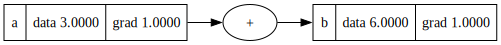

In [4]:
# Bug
# a + a computes derivarive of a with respect to a incorrectly.
# The derivative of a + a with respect to a should be 2, but it is computed as 1 in the current implementation.
a = Value(3.0, label="a")
b = a + a
b.label = "b"
b.backward()
draw_dot(b, rankdir="LR")

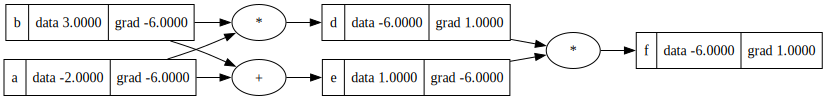

In [5]:
# Another example of the same bug:
a = Value(-2.0, label="a")
b = Value(3.0, label="b")
d = a * b
d.label = "d"
e = a + b
e.label = "e"
f = d * e
f.label = "f"

f.backward()

draw_dot(f, rankdir="LR")